<a href="https://colab.research.google.com/github/lydiadipaola/grand-isle-water-level-ml/blob/main/NOAA_2021_LinearReg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Grand Isle, Louisiana: Short-Term Water-Level Prediction

Objective: Predict one-hour-ahead coastal water levels at NOAA station 8761724 (Grand Isle, Louisiana) using historical water-level observations.

Data: NOAA hourly water-level observations, 2021.

Predictors: Water levels lagged by 1, 2, 3, 6, 12, and 24 hours.

Target: Water level one hour ahead.

Validation: Chronological 80/20 train-test split.

Evaluation: Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R².

Overview: This project evaluates whether machine-learning and statistical models can use recent water-level observations to predict short-term coastal water-level variability.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
url = "https://api.tidesandcurrents.noaa.gov/api/prod/datagetter?begin_date=20210101&end_date=20211231&station=8761724&product=hourly_height&datum=STND&time_zone=gmt&units=metric&format=csv"

df = pd.read_csv(url)

# Clean column names
df.columns = df.columns.str.strip()

# Check the data
df.head()

,Date Time,Water Level,Sigma,I,L
0,2021-01-01 00:00,2.424,0.000,0,0
1,2021-01-01 01:00,2.483,0.009,0,0
2,2021-01-01 02:00,2.514,0.007,0,0
3,2021-01-01 03:00,2.550,0.005,0,0
4,2021-01-01 04:00,2.563,0.006,0,0


In [ ]:
# Convert date/time
df["Date Time"] = pd.to_datetime(df["Date Time"])

# Sort chronologically
df = df.sort_values("Date Time").reset_index(drop=True)

# Create lagged predictors
df["level_1h"] = df["Water Level"].shift(1)
df["level_2h"] = df["Water Level"].shift(2)
df["level_3h"] = df["Water Level"].shift(3)
df["level_6h"] = df["Water Level"].shift(6)
df["level_12h"] = df["Water Level"].shift(12)
df["level_24h"] = df["Water Level"].shift(24)

# Target = water level one hour in the future
df["target"] = df["Water Level"].shift(-1)

# Remove rows with missing lag/target values
ml_df = df.dropna().reset_index(drop=True)

print("ML observations:", len(ml_df))

ML observations: 8735


In [ ]:
features = [
    "level_1h",
    "level_2h",
    "level_3h",
    "level_6h",
    "level_12h",
    "level_24h"
]

X = ml_df[features]
y = ml_df["target"]

print("Predictors:", features)
print("X shape:", X.shape)
print("y shape:", y.shape)

Predictors: ['level_1h', 'level_2h', 'level_3h', 'level_6h', 'level_12h', 'level_24h']
X shape: (8735, 6)
y shape: (8735,)


In [ ]:
split = int(len(ml_df) * 0.80)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

print("\nTraining period:")
print(ml_df["Date Time"].iloc[0], "to", ml_df["Date Time"].iloc[split - 1])

print("\nTesting period:")
print(ml_df["Date Time"].iloc[split], "to", ml_df["Date Time"].iloc[-1])

Training observations: 6988
Testing observations: 1747

Training period:
2021-01-02 00:00:00 to 2021-10-20 03:00:00

Testing period:
2021-10-20 04:00:00 to 2021-12-31 22:00:00


In [ ]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [ ]:
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print(f"Linear Regression MAE:  {lr_mae:.3f} m")
print(f"Linear Regression RMSE: {lr_rmse:.3f} m")
print(f"Linear Regression R²:   {lr_r2:.3f}")

Linear Regression MAE:  0.022 m
Linear Regression RMSE: 0.030 m
Linear Regression R²:   0.968


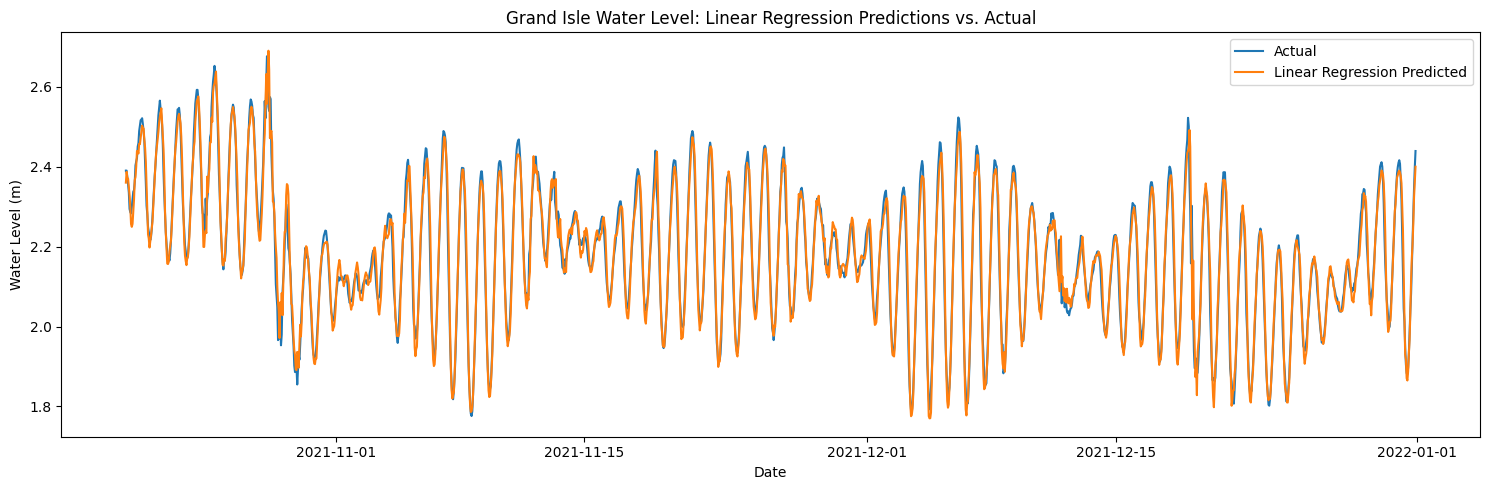

In [ ]:
lr_results = pd.DataFrame({
    "Date Time": ml_df["Date Time"].iloc[split:],
    "Actual": y_test.values,
    "Predicted": lr_pred
})

plt.figure(figsize=(15, 5))

plt.plot(
    lr_results["Date Time"],
    lr_results["Actual"],
    label="Actual"
)

plt.plot(
    lr_results["Date Time"],
    lr_results["Predicted"],
    label="Linear Regression Predicted"
)

plt.title("Grand Isle Water Level: Linear Regression Predictions vs. Actual")
plt.xlabel("Date")
plt.ylabel("Water Level (m)")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Examine Linear Regression coefficients

coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": lr_model.coef_
})

coefficients["Absolute Coefficient"] = abs(coefficients["Coefficient"])

coefficients = coefficients.sort_values(
    "Absolute Coefficient",
    ascending=False
)

display(coefficients)

,Feature,Coefficient,Absolute Coefficient
0,level_1h,1.186501,1.186501
3,level_6h,-0.491619,0.491619
4,level_12h,0.215581,0.215581
5,level_24h,0.060259,0.060259
1,level_2h,0.020939,0.020939
2,level_3h,-0.020555,0.020555


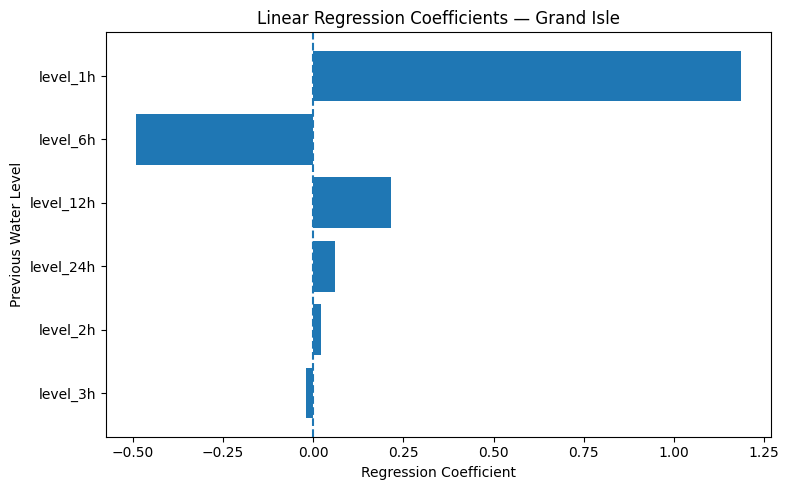

In [ ]:
plt.figure(figsize=(8, 5))

plt.barh(
    coefficients["Feature"],
    coefficients["Coefficient"]
)

plt.axvline(0, linestyle="--")

plt.xlabel("Regression Coefficient")
plt.ylabel("Previous Water Level")
plt.title("Linear Regression Coefficients — Grand Isle")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

The linear regression coefficients indicate that the most recent water-level observation (level_1h) was the strongest predictor of one-hour-ahead water level. Longer lagged observations contributed additional information, although their coefficients were smaller and varied in sign. Because lagged water-level predictors are strongly correlated within a tidal time series, individual coefficients should be interpreted as conditional model coefficients rather than independent physical effects.